<a href="https://colab.research.google.com/github/Ebad-ur-Rehman/Confidence-in-Medical-LLM-Question-Answering-A-Calibration-Study/blob/main/calibration_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Confidence Calibration in Medical LLM QA
Poster experiment: does stated confidence track actual correctness on MedQA?



## Package Installation

In [2]:
!pip install -q google-genai datasets pandas matplotlib numpy


## Gemini API key


In [3]:
API_KEY = "Paste Your Gemini API key"  # <-- place your key to run these experiment

from google import genai
client = genai.Client(api_key=API_KEY)

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

## Experiment Configuration



In [4]:
N_QUESTIONS = 120
SEED = 42
MODELS = [
    "gemini-3.1-flash-lite",
    "gemini-3.6-flash",
    "gemini-3.8-flash",
]
SLEEP_BETWEEN_CALLS = 2.0
OUTPUT_CSV = "calibration_results_raw.csv"


## Load MedQA Dataset

In [7]:
from datasets import load_dataset
import random

print("Loading MedQA...")
ds = load_dataset("GBaker/MedQA-USMLE-4-options", split="test")
print(f"Full test set size: {len(ds)}")

random.seed(SEED)
indices = random.sample(range(len(ds)), N_QUESTIONS)
sample = ds.select(indices)
print(f"Sampled {len(sample)} questions (seed={SEED})")

print(sample[0])


Loading MedQA...


README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl: reconstructing file:   0%|          |  0.00B / 16.2MB            

phrases_no_exclude_train.jsonl: downloading bytes:           |  0.00B            

phrases_no_exclude_test.jsonl:   0%|          | 0.00/2.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1273 [00:00<?, ? examples/s]

Full test set size: 1273
Sampled 120 questions (seed=42)
{'question': 'A 21-year-old male presents to his primary care provider for fatigue. He reports that he graduated from college last month and returned 3 days ago from a 2 week vacation to Vietnam and Cambodia. For the past 2 days, he has developed a worsening headache, malaise, and pain in his hands and wrists. The patient has a past medical history of asthma managed with albuterol as needed. He is sexually active with both men and women, and he uses condoms “most of the time.” On physical exam, the patient’s temperature is 102.5°F (39.2°C), blood pressure is 112/66 mmHg, pulse is 105/min, respirations are 12/min, and oxygen saturation is 98% on room air. He has tenderness to palpation over his bilateral metacarpophalangeal joints and a maculopapular rash on his trunk and upper thighs. Tourniquet test is negative. Laboratory results are as follows:\n\nHemoglobin: 14 g/dL\nHematocrit: 44%\nLeukocyte count: 3,200/mm^3\nPlatelet coun

## Prompt template and response parser

In [8]:
import re

ANSWER_PATTERN = re.compile(r"ANSWER\s*:\s*([A-D])", re.IGNORECASE)
CONFIDENCE_PATTERN = re.compile(r"CONFIDENCE\s*:\s*(\d{1,3})\s*%?", re.IGNORECASE)

PROMPT_TEMPLATE = """You are answering a medical licensing exam question. Read the question and options carefully, then respond in EXACTLY this format and nothing else:

ANSWER: <letter>
CONFIDENCE: <integer 0-100>

Question: {question}

Options:
{options_block}
"""

def parse_response(text):
    answer, confidence = None, None
    a_match = ANSWER_PATTERN.search(text)
    if a_match:
        answer = a_match.group(1).upper()
    c_match = CONFIDENCE_PATTERN.search(text)
    if c_match:
        val = int(c_match.group(1))
        confidence = max(0, min(100, val))
    return answer, confidence

def build_prompt(question, options):
    options_block = "\n".join(f"{k}. {v}" for k, v in options.items())
    return PROMPT_TEMPLATE.format(question=question, options_block=options_block)

# --- Quick self-test before spending API calls ---
test_cases = [
    ("ANSWER: B\nCONFIDENCE: 85", "B", 85),
    ("Based on the symptoms, ANSWER: A\nCONFIDENCE: 60", "A", 60),
    ("I think this could be several things...", None, None),
]
for text, exp_a, exp_c in test_cases:
    a, c = parse_response(text)
    status = "OK" if (a, c) == (exp_a, exp_c) else "MISMATCH"
    print(f"[{status}] {text!r} -> ({a}, {c})")


[OK] 'ANSWER: B\nCONFIDENCE: 85' -> (B, 85)
[OK] 'Based on the symptoms, ANSWER: A\nCONFIDENCE: 60' -> (A, 60)
[OK] 'I think this could be several things...' -> (None, None)


## Verifyung the dataset's field names



In [9]:
example = sample[0]
print("Keys:", list(example.keys()))
print(example)


Keys: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases']
{'question': 'A 21-year-old male presents to his primary care provider for fatigue. He reports that he graduated from college last month and returned 3 days ago from a 2 week vacation to Vietnam and Cambodia. For the past 2 days, he has developed a worsening headache, malaise, and pain in his hands and wrists. The patient has a past medical history of asthma managed with albuterol as needed. He is sexually active with both men and women, and he uses condoms “most of the time.” On physical exam, the patient’s temperature is 102.5°F (39.2°C), blood pressure is 112/66 mmHg, pulse is 105/min, respirations are 12/min, and oxygen saturation is 98% on room air. He has tenderness to palpation over his bilateral metacarpophalangeal joints and a maculopapular rash on his trunk and upper thighs. Tourniquet test is negative. Laboratory results are as follows:\n\nHemoglobin: 14 g/dL\nHematocrit: 44%\nLeukocyte cou

## Perform Experiment On Real Dataset MedQA 120 question



In [21]:
import time
import pandas as pd

rows = []
MAX_RETRIES = 5
RETRY_WAIT = 30  # seconds to wait after a 429 before retrying

for model_name in MODELS:
    print(f"\n=== Model: {model_name} ===")

    for i, item in enumerate(sample):
        question = item["question"]
        options = item["options"]          # ADJUST IF NEEDED
        correct_letter = item["answer_idx"]  # ADJUST IF NEEDED

        prompt = build_prompt(question, options)
        raw_text = ""

        for attempt in range(MAX_RETRIES):
            try:
                response = client.models.generate_content(model=model_name, contents=prompt)
                raw_text = response.text
                break
            except Exception as e:
                msg = str(e)
                if "429" in msg or "RESOURCE_EXHAUSTED" in msg:
                    print(f"  [{i}] rate-limited, waiting {RETRY_WAIT}s (attempt {attempt+1}/{MAX_RETRIES})")
                    time.sleep(RETRY_WAIT)
                    continue
                else:
                    print(f"  [{i}] API error: {msg[:150]}")
                    break

        pred_letter, confidence = parse_response(raw_text)
        is_correct = (pred_letter == correct_letter) if pred_letter else False

        rows.append({
            "model": model_name,
            "question_idx": i,
            "correct_letter": correct_letter,
            "predicted_letter": pred_letter,
            "confidence": confidence,
            "is_correct": is_correct,
            "raw_response": raw_text.replace("\n", " | "),
        })

        if i % 10 == 0:
            print(f"  [{i}/{len(sample)}] pred={pred_letter} conf={confidence} correct={is_correct}")

        time.sleep(SLEEP_BETWEEN_CALLS)

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(df)} rows to {OUTPUT_CSV}")


=== Model: gemini-3.1-flash-lite ===
  [0/120] pred=A conf=90 correct=True
  [10/120] pred=D conf=100 correct=True
  [20/120] pred=B conf=100 correct=True
  [30/120] pred=C conf=90 correct=True
  [40/120] pred=C conf=95 correct=True
  [50/120] pred=A conf=100 correct=True
  [60/120] pred=D conf=95 correct=True
  [70/120] pred=C conf=100 correct=True
  [80/120] pred=D conf=100 correct=True
  [90/120] pred=B conf=100 correct=True
  [100/120] pred=D conf=90 correct=True
  [110/120] pred=D conf=100 correct=True

=== Model: gemini-3.6-flash ===
  [0/120] pred=A conf=95 correct=True
  [10/120] pred=D conf=100 correct=True
  [20/120] pred=B conf=100 correct=True
  [30/120] pred=C conf=95 correct=True
  [40/120] pred=C conf=95 correct=True
  [50/120] pred=A conf=95 correct=True
  [60/120] pred=D conf=95 correct=True
  [70/120] pred=C conf=95 correct=True
  [80/120] pred=D conf=95 correct=True
  [90/120] pred=B conf=100 correct=True
  [100/120] pred=D conf=95 correct=True
  [110/120] pred=D co

## Perform Experiment On Synthetic Dataset 40 questions

In [13]:
import json
import time
import pandas as pd
from google.colab import files

uploaded = files.upload()  # upload synthetic_questions.json

with open("synthetic_questions_hard_v2.json") as f:
    synthetic_sample = json.load(f)

MODELS = ["gemini-3.1-flash-lite", "gemini-3.6-flash", "gemini-3.8-flash"]
SLEEP_BETWEEN_CALLS = 2.0
MAX_RETRIES = 3
RETRY_WAIT = 20

rows = []
for model_name in MODELS:
    print(f"\n=== Model: {model_name} ===")
    for item in synthetic_sample:
        i = item["id"]
        question = item["question"]
        options = item["options"]
        correct_letter = item["answer_idx"]
        prompt = build_prompt(question, options)
        raw_text = ""
        for attempt in range(MAX_RETRIES):
            try:
                response = client.models.generate_content(model=model_name, contents=prompt)
                raw_text = response.text
                break
            except Exception as e:
                msg = str(e)
                if "429" in msg or "RESOURCE_EXHAUSTED" in msg:
                    print(f"  [{i}] rate-limited, waiting {RETRY_WAIT}s")
                    time.sleep(RETRY_WAIT)
                    continue
                else:
                    raw_text = f"ERROR: {msg[:200]}"
                    break
        pred_letter, confidence = parse_response(raw_text)
        is_correct = (pred_letter == correct_letter) if pred_letter else False
        rows.append({"model": model_name, "question_idx": i, "specialty": item["specialty"],
                      "correct_letter": correct_letter, "predicted_letter": pred_letter,
                      "confidence": confidence, "is_correct": is_correct,
                      "raw_response": raw_text.replace("\n", " | ")})
        time.sleep(SLEEP_BETWEEN_CALLS)

df_synthetic = pd.DataFrame(rows)
df_synthetic.to_csv("results_synthetic.csv", index=False)
files.download("results_synthetic.csv")
print(df_synthetic.groupby("model")["is_correct"].mean())

Saving synthetic_questions_hard_v2.json to synthetic_questions_hard_v2.json

=== Model: gemini-3.1-flash-lite ===

=== Model: gemini-3.6-flash ===

=== Model: gemini-3.8-flash ===


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

model
gemini-3.1-flash-lite    1.0
gemini-3.6-flash         1.0
gemini-3.8-flash         1.0
Name: is_correct, dtype: float64


## Overall Summary

In [22]:
summary = df.groupby("model").agg(
    accuracy=("is_correct", "mean"),
    mean_confidence=("confidence", "mean"),
    n_unparseable=("predicted_letter", lambda x: x.isna().sum()),
)
print(summary)


                       accuracy  mean_confidence  n_unparseable
model                                                          
gemini-3.1-flash-lite  0.908333        98.416667              0
gemini-3.6-flash       0.975000        96.700000              0
gemini-3.8-flash       0.991667        96.766667              0


## Calibration analysis (ECE + charts)



Upload your MedQA results CSV:


Saving calibration_results_raw (1).csv to calibration_results_raw (1).csv

Upload your NOVEL HARD SET results CSV (results_synthetic_2.csv):


Saving results_synthetic (2).csv to results_synthetic (2).csv


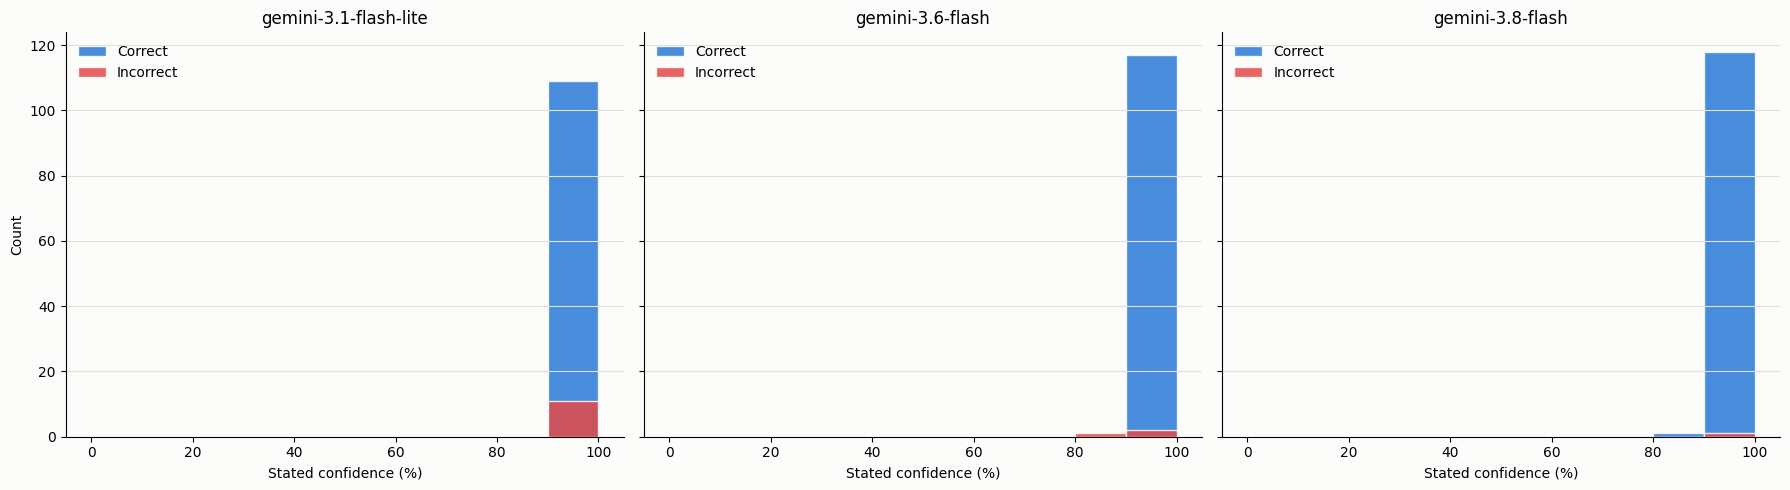

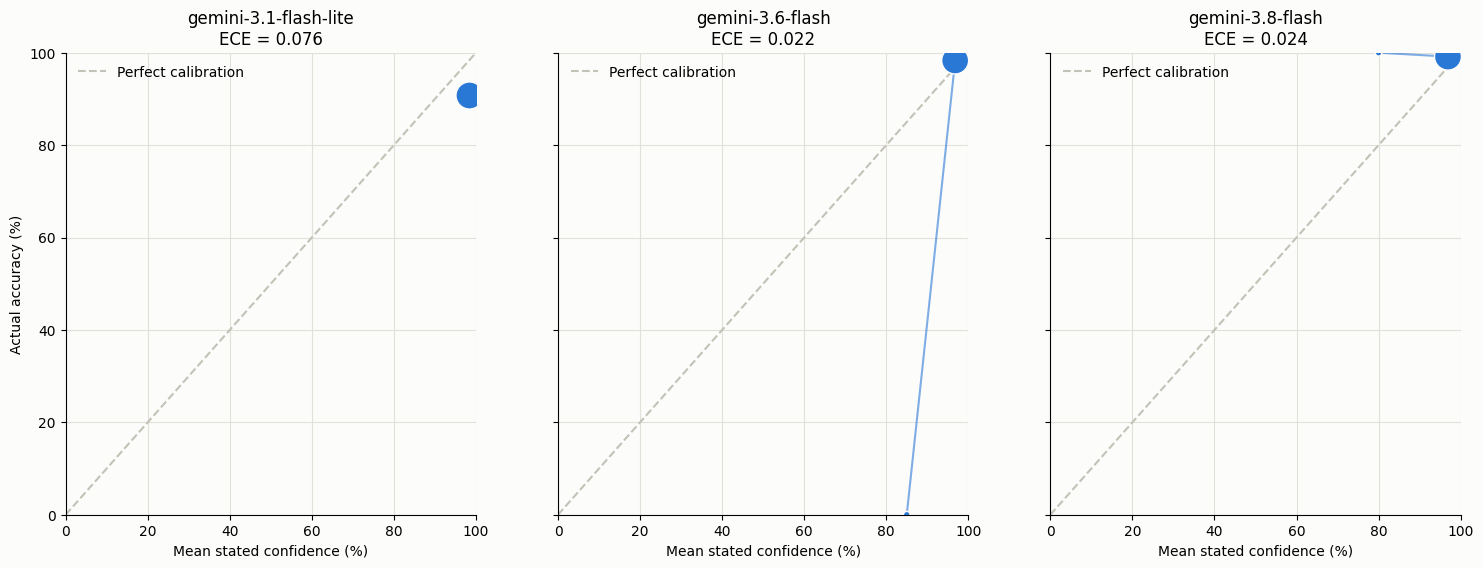

                model  accuracy_pct  mean_confidence_pct    ece
gemini-3.1-flash-lite         90.83                98.42 0.0758
     gemini-3.6-flash         97.50                96.70 0.0222
     gemini-3.8-flash         99.17                96.77 0.0240


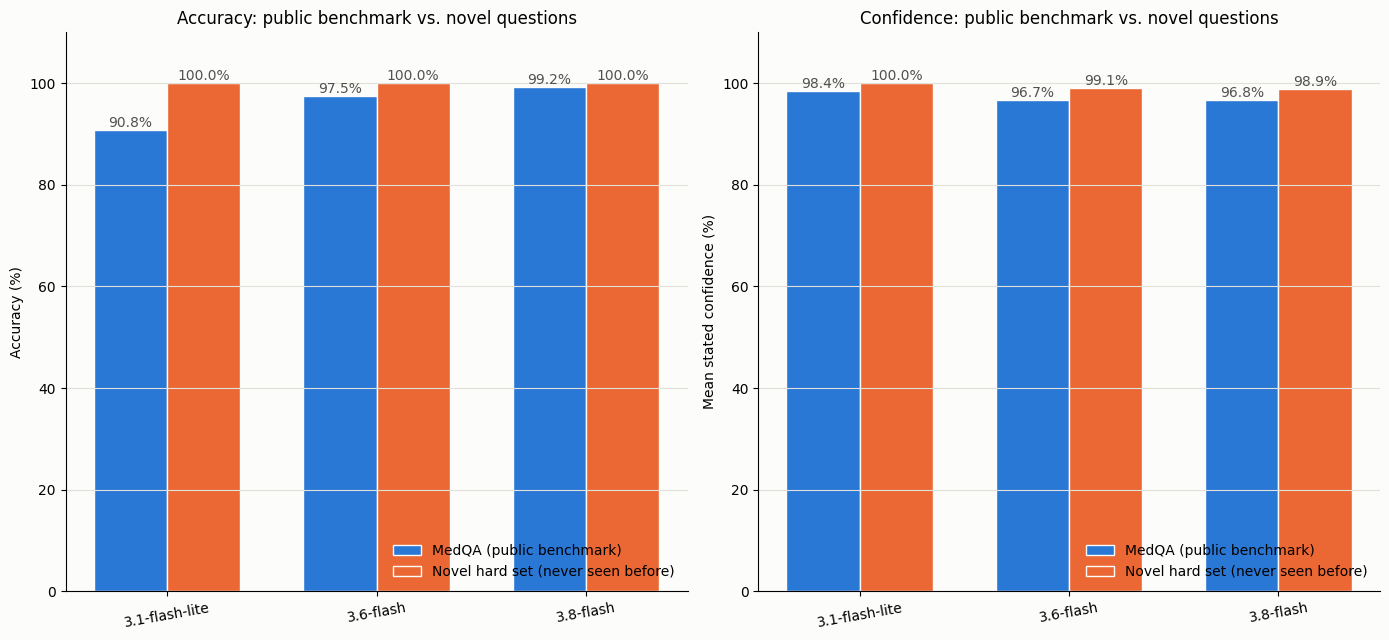

In [14]:
## Step 9 — Calibration analysis + MedQA vs. novel-set comparison (ECE + all 3 charts)
# Upload BOTH result CSVs when prompted: your MedQA results file, then your novel
# hard-set results file (results_synthetic_2.csv, the corrected v2 run).

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Upload your MedQA results CSV:")
uploaded = files.upload()
medqa_df = pd.read_csv(next(iter(uploaded)))

print("\nUpload your NOVEL HARD SET results CSV (results_synthetic_2.csv):")
uploaded2 = files.upload()
novel_df = pd.read_csv(next(iter(uploaded2)))

def expected_calibration_error(confidences, corrects, n_bins=10):
    confidences = np.asarray(confidences, dtype=float) / 100.0
    corrects = np.asarray(corrects, dtype=float)
    n = len(confidences)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_table = []
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences >= lo) & (confidences <= hi) if i == n_bins - 1 else (confidences >= lo) & (confidences < hi)
        count = mask.sum()
        if count == 0:
            bin_table.append({"mean_confidence": None, "accuracy": None, "count": 0})
            continue
        mean_conf = confidences[mask].mean()
        acc = corrects[mask].mean()
        ece += (count / n) * abs(acc - mean_conf)
        bin_table.append({"mean_confidence": mean_conf * 100, "accuracy": acc * 100, "count": int(count)})
    return ece, bin_table

COL_CORRECT = "#2a78d6"
COL_INCORRECT = "#e34948"
COL_NOVEL = "#eb6834"
COL_SURFACE = "#fcfcfb"
COL_GRIDLINE = "#e1e0d9"
COL_BASELINE = "#c3c2b7"
COL_SECONDARY = "#52514e"

models = medqa_df["model"].unique()
summary_rows = []

# --- Fig 1: confidence histogram, correct vs incorrect (MedQA) ---
fig_hist, axes_hist = plt.subplots(1, len(models), figsize=(6 * len(models), 5), sharey=True, facecolor=COL_SURFACE)
if len(models) == 1:
    axes_hist = [axes_hist]

# --- Fig 2: calibration curve (MedQA) ---
fig_cal, axes_cal = plt.subplots(1, len(models), figsize=(6 * len(models), 6), sharey=True, facecolor=COL_SURFACE)
if len(models) == 1:
    axes_cal = [axes_cal]

for idx, model_name in enumerate(models):
    sub = medqa_df[medqa_df["model"] == model_name].dropna(subset=["confidence"])
    confidences = sub["confidence"].astype(float).values
    corrects = sub["is_correct"].astype(int).values
    ece, bin_table = expected_calibration_error(confidences, corrects)

    summary_rows.append({
        "model": model_name,
        "accuracy_pct": round(corrects.mean() * 100, 2),
        "mean_confidence_pct": round(confidences.mean(), 2),
        "ece": round(ece, 4),
    })

    ax = axes_hist[idx]
    ax.set_facecolor(COL_SURFACE)
    bins = np.linspace(0, 100, 11)
    ax.hist(confidences[corrects == 1], bins=bins, alpha=0.85, label="Correct", color=COL_CORRECT, edgecolor=COL_SURFACE)
    ax.hist(confidences[corrects == 0], bins=bins, alpha=0.85, label="Incorrect", color=COL_INCORRECT, edgecolor=COL_SURFACE)
    ax.set_title(model_name)
    ax.set_xlabel("Stated confidence (%)")
    if idx == 0:
        ax.set_ylabel("Count")
    ax.grid(axis="y", color=COL_GRIDLINE)
    ax.legend(frameon=False)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

    ax2 = axes_cal[idx]
    ax2.set_facecolor(COL_SURFACE)
    xs = [b["mean_confidence"] for b in bin_table if b["count"] > 0]
    ys = [b["accuracy"] for b in bin_table if b["count"] > 0]
    sizes = [b["count"] for b in bin_table if b["count"] > 0]
    ax2.plot([0, 100], [0, 100], linestyle="--", color=COL_BASELINE, label="Perfect calibration")
    ax2.scatter(xs, ys, s=[20 + s * 3 for s in sizes], color=COL_CORRECT, edgecolor=COL_SURFACE, zorder=3)
    ax2.plot(xs, ys, color=COL_CORRECT, alpha=0.6, zorder=2)
    ax2.set_xlim(0, 100); ax2.set_ylim(0, 100)
    ax2.set_title(f"{model_name}\nECE = {ece:.3f}")
    ax2.set_xlabel("Mean stated confidence (%)")
    if idx == 0:
        ax2.set_ylabel("Actual accuracy (%)")
    ax2.grid(color=COL_GRIDLINE)
    ax2.legend(frameon=False, loc="upper left")
    for s in ["top", "right"]:
        ax2.spines[s].set_visible(False)

fig_hist.tight_layout()
fig_hist.savefig("confidence_histogram.png", dpi=200, facecolor=COL_SURFACE)
plt.show()

fig_cal.tight_layout()
fig_cal.savefig("calibration_curve.png", dpi=200, facecolor=COL_SURFACE)
plt.show()

print(pd.DataFrame(summary_rows).to_string(index=False))

# --- Fig 3: MedQA vs novel hard set comparison ---
medqa_acc, medqa_conf, synth_acc, synth_conf = [], [], [], []
for m in models:
    mq = medqa_df[medqa_df["model"] == m].dropna(subset=["confidence"])
    nv = novel_df[novel_df["model"] == m].dropna(subset=["confidence"])
    medqa_acc.append(mq["is_correct"].astype(int).mean() * 100)
    medqa_conf.append(mq["confidence"].astype(float).mean())
    synth_acc.append(nv["is_correct"].astype(int).mean() * 100)
    synth_conf.append(nv["confidence"].astype(float).mean())

x = np.arange(len(models))
width = 0.35
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6.5), facecolor=COL_SURFACE)

ax = axes3[0]
ax.set_facecolor(COL_SURFACE)
b1 = ax.bar(x - width/2, medqa_acc, width, label="MedQA (public benchmark)", color=COL_CORRECT, edgecolor=COL_SURFACE)
b2 = ax.bar(x + width/2, synth_acc, width, label="Novel hard set (never seen before)", color=COL_NOVEL, edgecolor=COL_SURFACE)
ax.set_ylim(0, 110); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy: public benchmark vs. novel questions")
ax.set_xticks(x); ax.set_xticklabels([m.replace("gemini-", "") for m in models], rotation=10)
ax.grid(axis="y", color=COL_GRIDLINE)
ax.legend(frameon=False, loc="lower right")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width()/2, h), ha="center", va="bottom", fontsize=10, color=COL_SECONDARY)

ax2 = axes3[1]
ax2.set_facecolor(COL_SURFACE)
b3 = ax2.bar(x - width/2, medqa_conf, width, label="MedQA (public benchmark)", color=COL_CORRECT, edgecolor=COL_SURFACE)
b4 = ax2.bar(x + width/2, synth_conf, width, label="Novel hard set (never seen before)", color=COL_NOVEL, edgecolor=COL_SURFACE)
ax2.set_ylim(0, 110); ax2.set_ylabel("Mean stated confidence (%)")
ax2.set_title("Confidence: public benchmark vs. novel questions")
ax2.set_xticks(x); ax2.set_xticklabels([m.replace("gemini-", "") for m in models], rotation=10)
ax2.grid(axis="y", color=COL_GRIDLINE)
ax2.legend(frameon=False, loc="lower right")
for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)
for bars in (b3, b4):
    for bar in bars:
        h = bar.get_height()
        ax2.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width()/2, h), ha="center", va="bottom", fontsize=10, color=COL_SECONDARY)

fig3.tight_layout()
fig3.savefig("dataset_comparison.png", dpi=200, facecolor=COL_SURFACE)
plt.show()

## Download Result Images



In [15]:
from google.colab import files
files.download("confidence_histogram.png")
files.download("calibration_curve.png")
files.download("dataset_comparison.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>